DATASET OVERVIEW


/tmp/ipykernel_762/1627688249.py:7: DtypeWarning: Columns (29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("US_Accidents_500k.csv")


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day



Shape : (64087, 46)

Missing Values
ID                           0
Source                       0
Severity                     0
Start_Time                   0
End_Time                     0
Start_Lat                    0
Start_Lng                    0
End_Lat                  64087
End_Lng                  64087
Distance(mi)                 0
Description                  0
Street                       0
City                         0
County                       0
State                        0
Zipcode                      7
Country                      1
Timezone                     8
Airport_Code                 8
Weather_Timestamp          496
Temperature(F)             798
Wind_Chill(F)            61017
Humidity(%)               1018
Pressure(in)               590
Visibility(mi)            1076
Wind_Direction             497
Wind_Speed(mph)          13329
Precipitation(in)        58965
Weather_Condition          889
Amenity                      1
Bump                         1
Cr

/tmp/ipykernel_762/1627688249.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Weather_Condition"].fillna("Unknown", inplace=True)
/tmp/ipykernel_762/1627688249.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

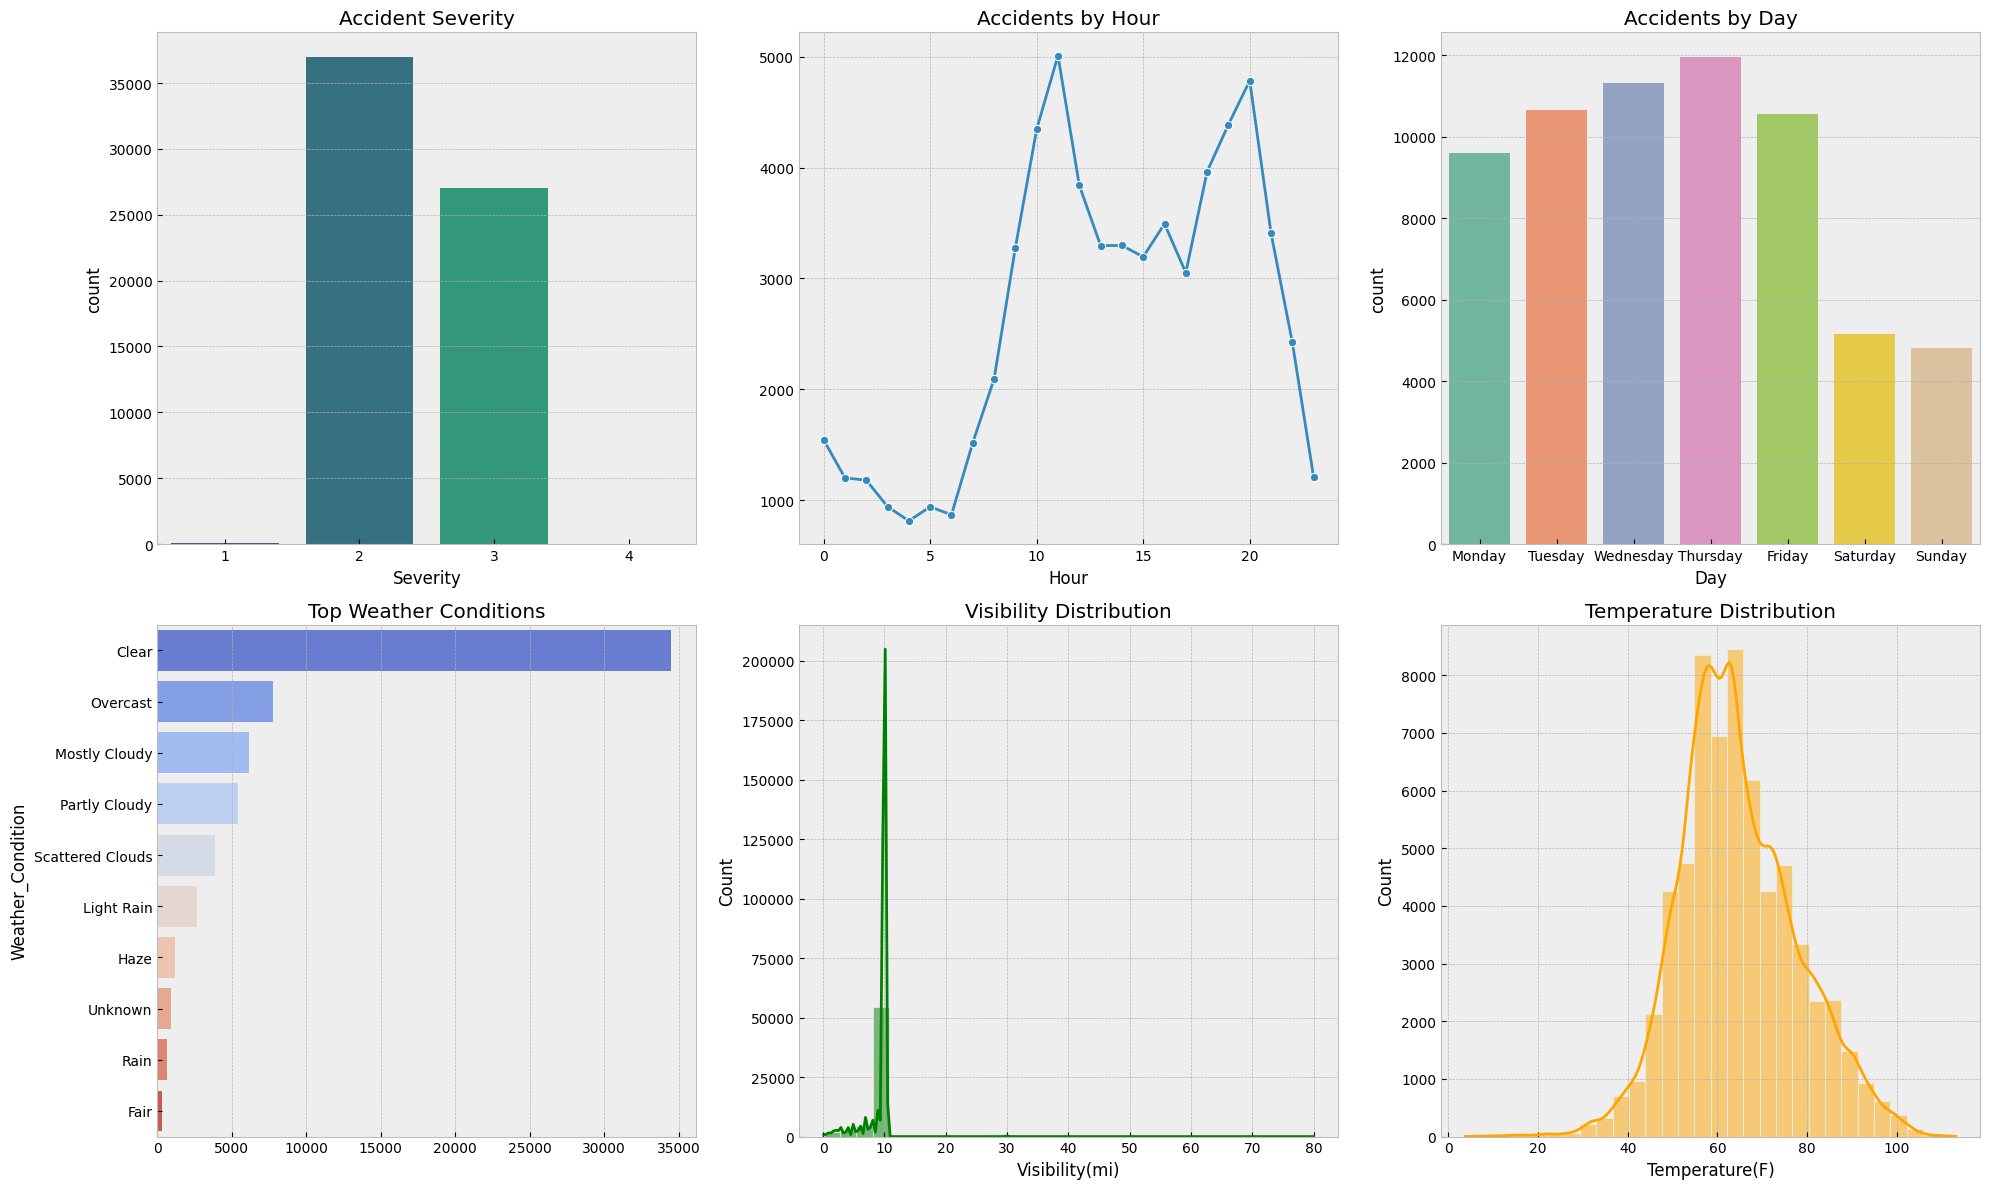

/tmp/ipykernel_762/1627688249.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


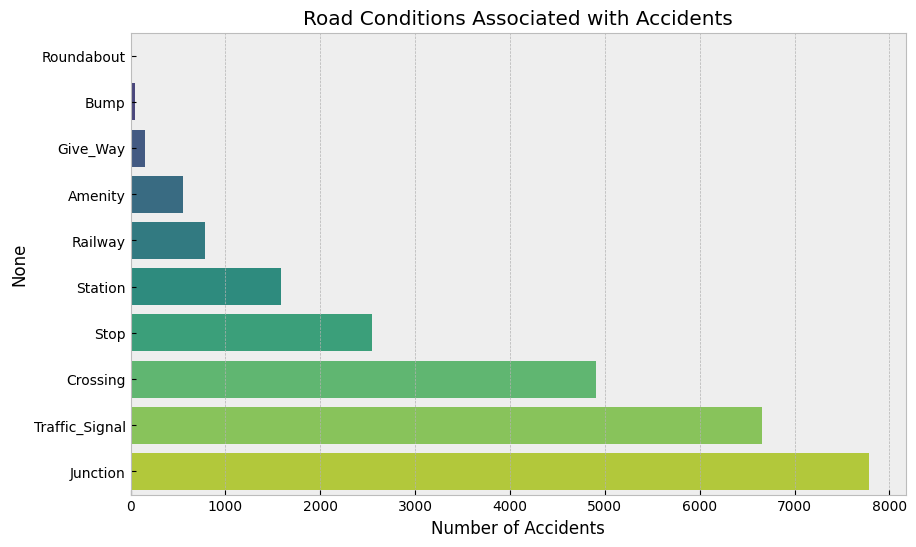

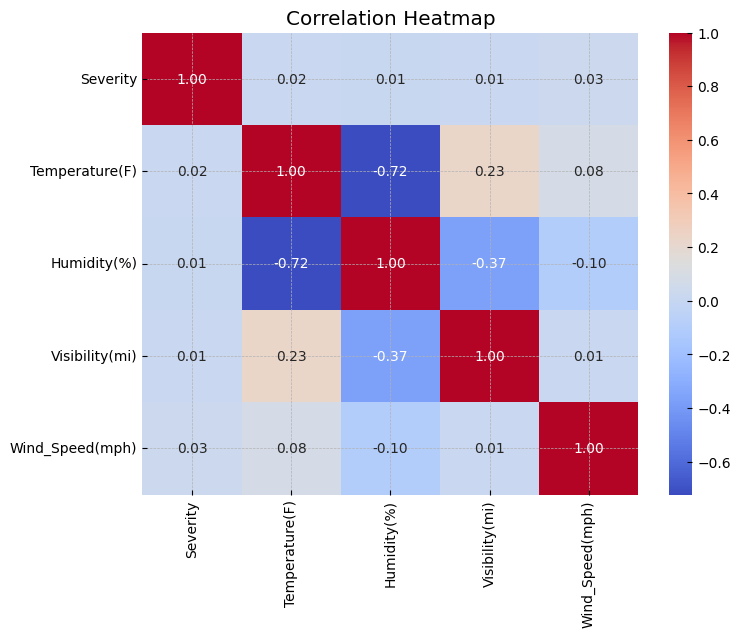

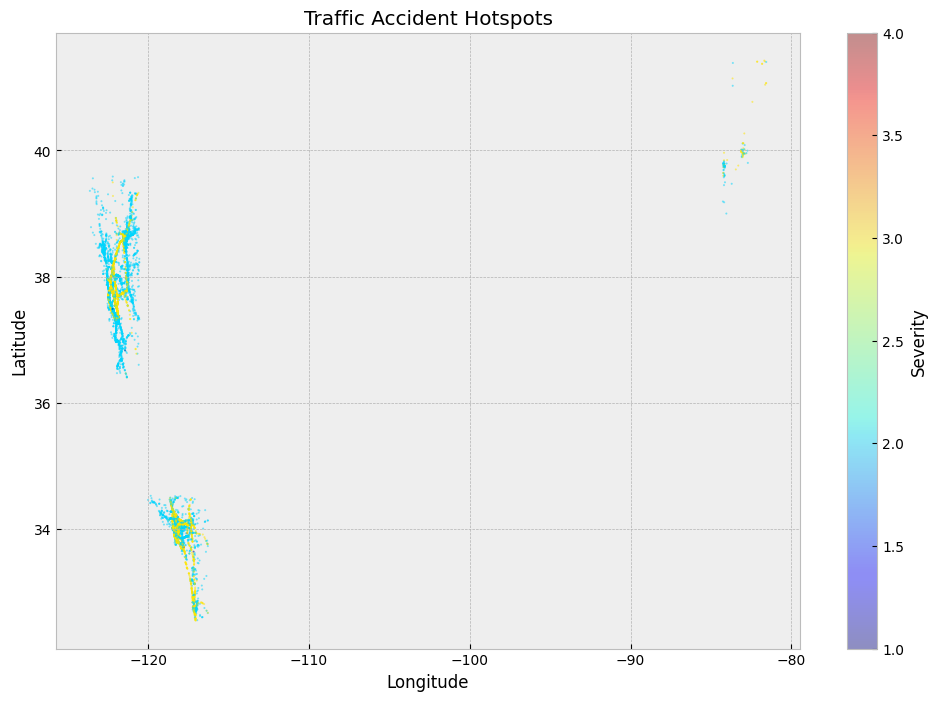

KEY OBSERVATIONS
• Most accidents occur during daytime commuting hours.
• Weather conditions significantly influence accident occurrence.
• Reduced visibility is associated with more accidents.
• Junctions and traffic signals are among the most common road features involved.
• Accident hotspots are concentrated in densely populated regions.
• Severity shows a weak correlation with weather variables.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("bmh")

df = pd.read_csv("US_Accidents_500k.csv")

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

display(df.head())

print("\nShape :", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

df["Weather_Condition"].fillna("Unknown", inplace=True)
df["Temperature(F)"].fillna(df["Temperature(F)"].median(), inplace=True)
df["Visibility(mi)"].fillna(df["Visibility(mi)"].median(), inplace=True)
df["Humidity(%)"].fillna(df["Humidity(%)"].median(), inplace=True)
df["Wind_Speed(mph)"].fillna(df["Wind_Speed(mph)"].median(), inplace=True)

df["Start_Time"] = pd.to_datetime(df["Start_Time"])

df["Hour"] = df["Start_Time"].dt.hour
df["Day"] = df["Start_Time"].dt.day_name()

fig, ax = plt.subplots(2,3,figsize=(20,12))

sns.countplot(
    data=df,
    x="Severity",
    palette="viridis",
    ax=ax[0,0]
)

ax[0,0].set_title("Accident Severity")

hourly=df.groupby("Hour").size()

sns.lineplot(
    x=hourly.index,
    y=hourly.values,
    marker="o",
    ax=ax[0,1]
)

ax[0,1].set_title("Accidents by Hour")

sns.countplot(
    data=df,
    x="Day",
    order=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ],
    palette="Set2",
    ax=ax[0,2]
)

ax[0,2].set_title("Accidents by Day")

top_weather=df["Weather_Condition"].value_counts().head(10)

sns.barplot(
    x=top_weather.values,
    y=top_weather.index,
    palette="coolwarm",
    ax=ax[1,0]
)

ax[1,0].set_title("Top Weather Conditions")

sns.histplot(
    df["Visibility(mi)"],
    bins=30,
    color="green",
    kde=True,
    ax=ax[1,1]
)

ax[1,1].set_title("Visibility Distribution")

sns.histplot(
    df["Temperature(F)"],
    bins=30,
    color="orange",
    kde=True,
    ax=ax[1,2]
)

ax[1,2].set_title("Temperature Distribution")

plt.tight_layout()
plt.show()

road_features=[
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Signal"
]

road_counts=df[road_features].sum().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(
    x=road_counts.values,
    y=road_counts.index,
    palette="viridis"
)

plt.title("Road Conditions Associated with Accidents")
plt.xlabel("Number of Accidents")

plt.show()

plt.figure(figsize=(8,6))

numeric=df[
    [
        "Severity",
        "Temperature(F)",
        "Humidity(%)",
        "Visibility(mi)",
        "Wind_Speed(mph)"
    ]
]

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

sample=df.sample(10000,random_state=42)

plt.figure(figsize=(12,8))

plt.scatter(
    sample["Start_Lng"],
    sample["Start_Lat"],
    s=1,
    alpha=0.4,
    c=sample["Severity"],
    cmap="jet"
)

plt.colorbar(label="Severity")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Traffic Accident Hotspots")

plt.show()

print("="*60)
print("KEY OBSERVATIONS")
print("="*60)

print("• Most accidents occur during daytime commuting hours.")
print("• Weather conditions significantly influence accident occurrence.")
print("• Reduced visibility is associated with more accidents.")
print("• Junctions and traffic signals are among the most common road features involved.")
print("• Accident hotspots are concentrated in densely populated regions.")
print("• Severity shows a weak correlation with weather variables.")